In [1]:
import numpy as np
import scipy.stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import copy
import scipy.integrate as integrate

np.random.seed(55)

# Task 1

## A

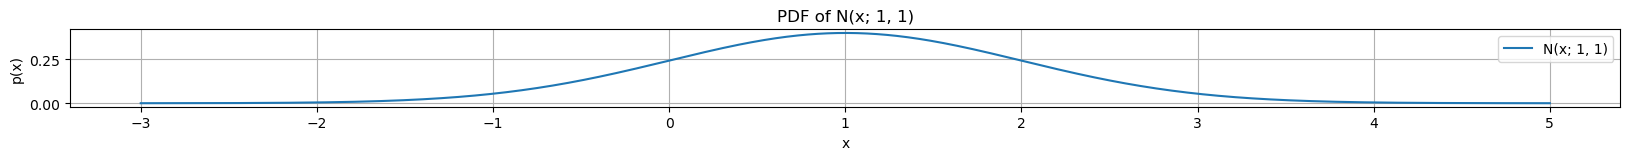

In [2]:
x = np.linspace(-3, 5, 1000)
# calculate PDF of Gaussian distribution
pdf = norm.pdf(x, 1, 1)

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
ax.plot(x, pdf, label="N(x; 1, 1)")
ax.set_aspect('equal')
ax.grid(True)
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('PDF of N(x; 1, 1)')
ax.legend()

## B

In [3]:
p = norm.cdf(0, loc=1, scale=1)
print(f"Probability mass that X <= 0 is {p}")

Probability mass that X <= 0 is 0.15865525393145707


## C

Bayes th.: $$p(x|z)=\frac{p(z|x)p(x)}{p(z)}=\eta p(z|x)p(x)=\eta*likelihood * prior$$
Normalization factor (using total probability rule): $$\eta^{-1}=p(z)=\int_{-\infty}^{+\infty}p(z,x)dx=\int_{-\infty}^{+\infty}p(z|x)p(x)dx$$

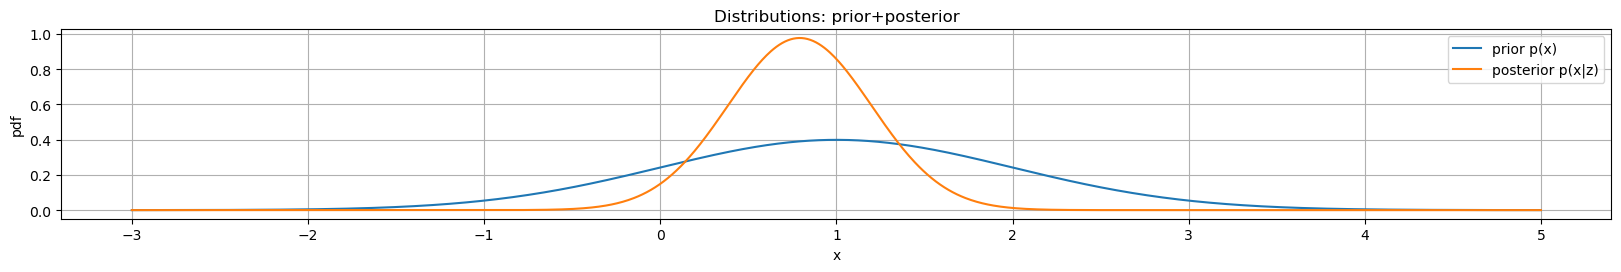

In [4]:
sigma2 = 0.2
z = 0.75

prior = copy.deepcopy(pdf)
likelihood = norm.pdf(z, x, np.sqrt(sigma2))
posterior = likelihood * prior

# calculate normalization factor (formula above)
posterior /= integrate.simpson(posterior, x=x)

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
ax.plot(x, prior, label="prior p(x)")
ax.plot(x, posterior, label='posterior p(x|z)')
ax.set_aspect('equal')
ax.grid(True)
ax.set_xlabel('x')
ax.set_ylabel('pdf')
ax.set_title('Distributions: prior+posterior')
ax.legend()

# Task 2

## A

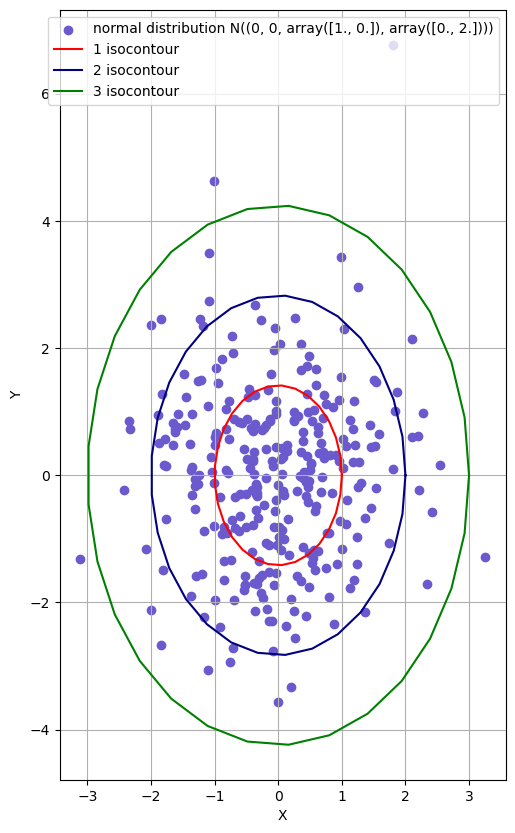

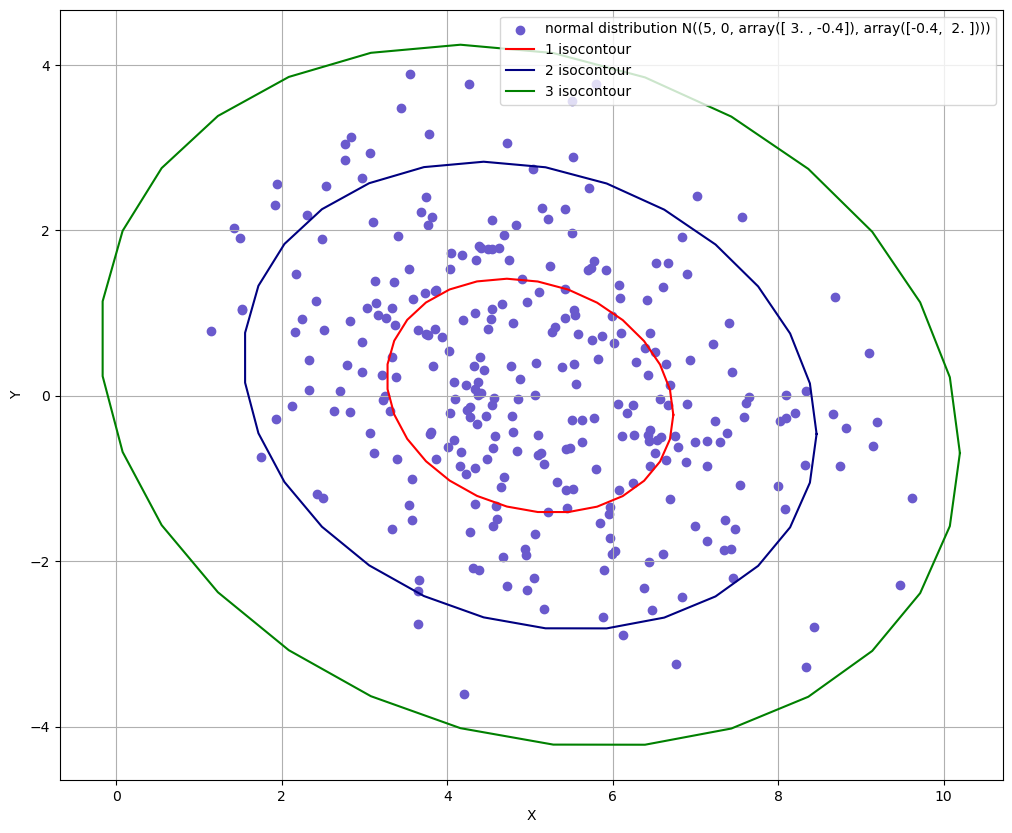

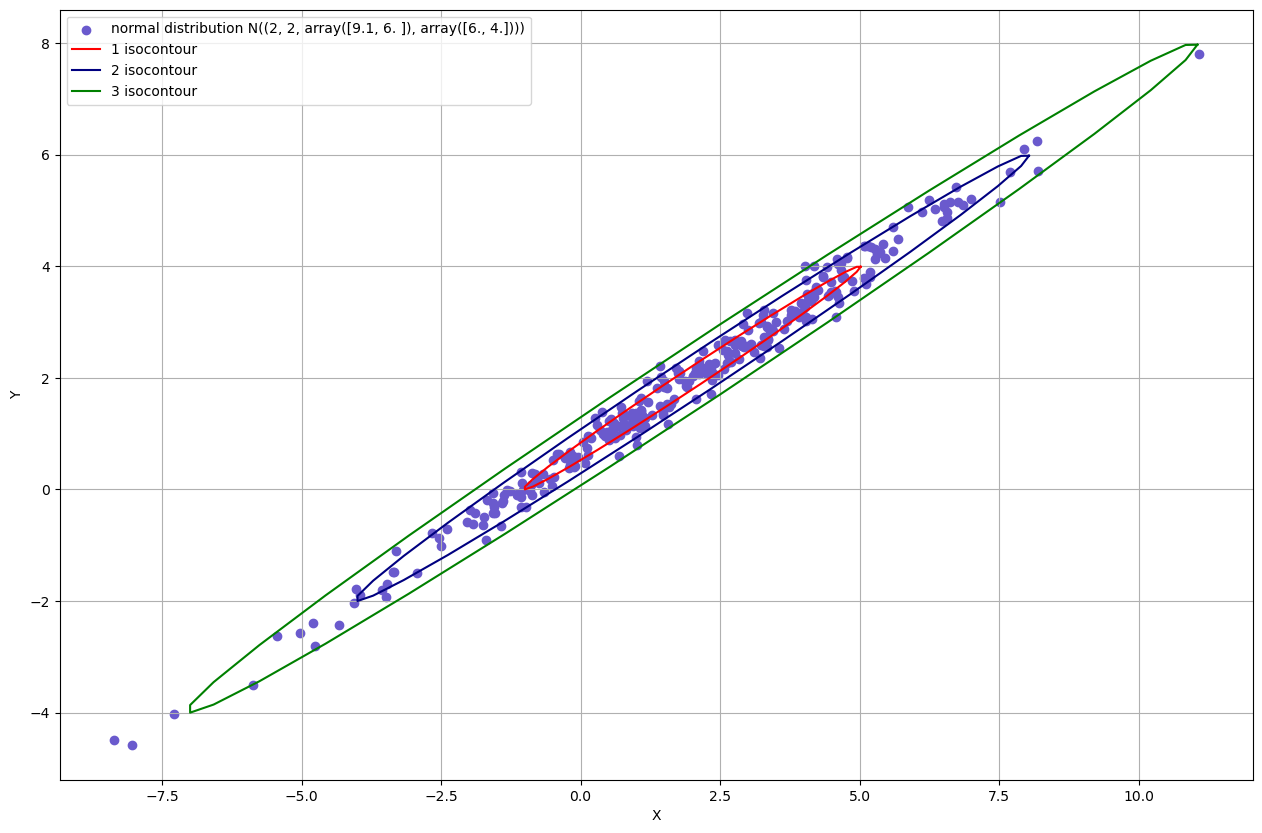

In [5]:
def linear_transformation(pts: np.ndarray, A: np.ndarray, b: np.ndarray) -> np.ndarray:
    """nonlinear_transformation performs linear transformation for given points

    Args:
        pts (np.ndarray): array of points with shape (n, 2)
        A (np.ndarray): matrix of linear transformation with shape (2, 2)
        b (np.ndarray): vector of biases with shape (2,)

    Returns:
        np.ndarray: transformed points
    """
    pts_new = (A @ pts.transpose() + b[:, None]).transpose()
    return pts_new

def plot2dcov(mean, cov, size=300, k=[1,2,3], ax=None, plot_univariate=False, plot_target=False, return_cloud=False, c=['r', 'navy', 'g']):
    if ax is None:
        fig = plt.figure(figsize=(20,10))
        ax = fig.add_subplot(111)

    A = np.linalg.cholesky(cov)

    if plot_target:
        cloud1 = np.random.multivariate_normal(mean, cov, size)
        # cloud = np.random.randn(300, 2) 
        # cloud1 = linear_transformation(cloud, A, mean) # only for diagonal covariance matrix!
        ax.scatter(cloud1[:, 0], cloud1[:, 1], label=f'normal distribution N({*np.round(mean, 3), *np.round(cov,3)})', c='slateblue')

    if plot_univariate:
        cloud = np.random.multivariate_normal(mean=np.array([0,0]), cov=np.array([[1,0],[0,1]]), size=size)
        ax.scatter(cloud[:,0], cloud[:,1], label='univariate distribution N(0,1)', color='orange')

    for i in range(len(k)):
        angles = np.linspace(0, np.pi*2, 30)
        points = np.hstack([np.cos(angles)[:, None], np.sin(angles)[:, None]]) * float(k[i])
        points_new = linear_transformation(points, A, mean)
        ax.plot(points_new[:, 0], points_new[:, 1], label=f'{k[i]} isocontour', c=c[i])
        
    ax.legend()
    ax.grid(True)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')

    if return_cloud:
        return cloud1, ax
    else:
        return None, ax


mean = np.array([[0,0], [5, 0], [2, 2]])
cov = np.array([[[1, 0], [0, 2]], [[3, -0.4], [-0.4, 2]], [[9.1, 6], [6, 4]]])

for i in range(mean.shape[0]):
    plot2dcov(mean[i], cov[i], plot_target=True)


## B

Sample mean:
$$\overline\mu = \frac{1}{N}\sum_{i=1}^N x_i$$

Sample covariance:
$$\overline\Sigma = \frac{1}{N - 1} \sum_{i=1}^N (x_i-\overline\mu)^T(x_i-\overline\mu)$$

## C

sample_cov: [[1.30533602 1.738238  ]
 [1.738238   4.34055137]]
sample_cov: [[0.97969876 1.19562906]
 [1.19562906 2.65238671]]
sample_cov: [[1.0418459  1.35663602]
 [1.35663602 3.18264787]]


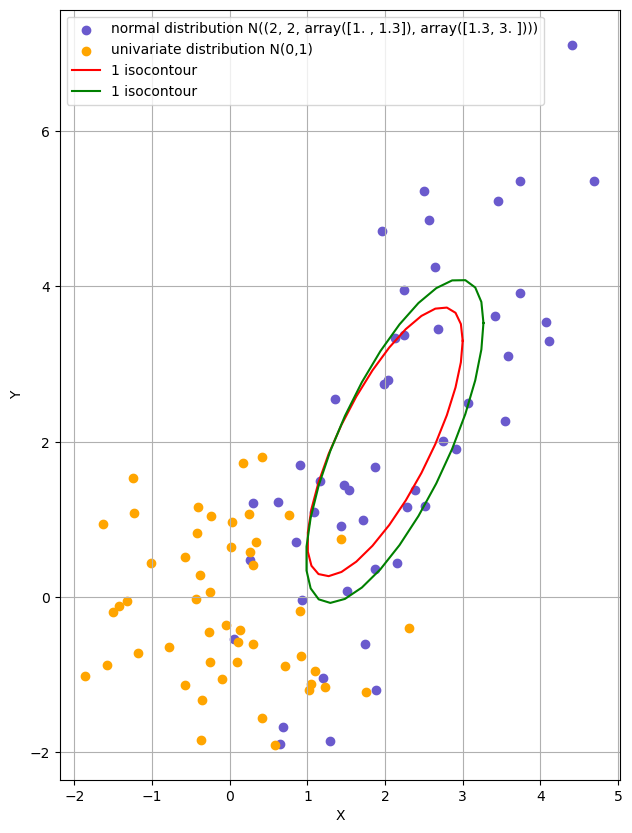

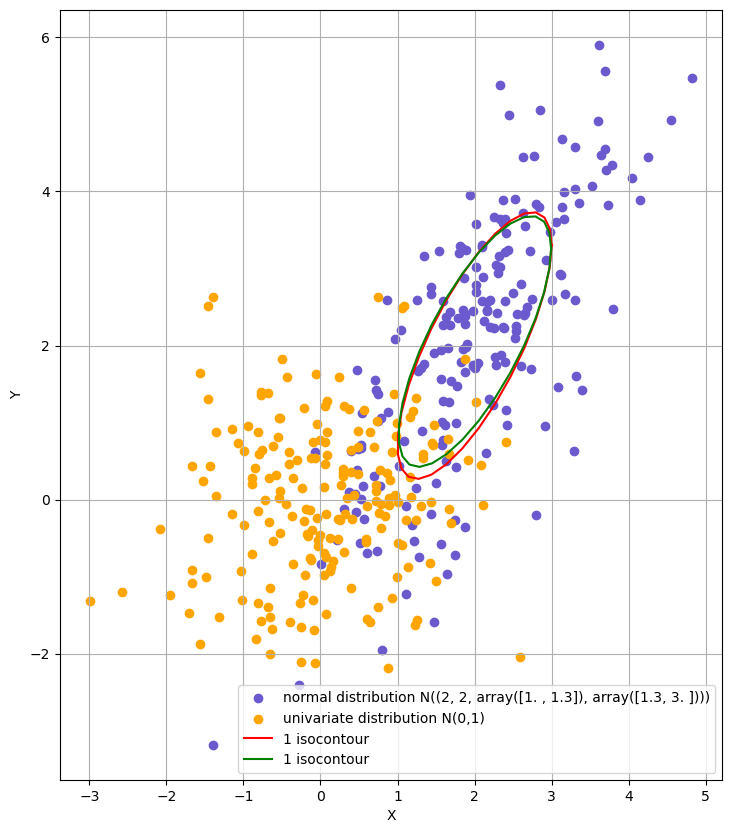

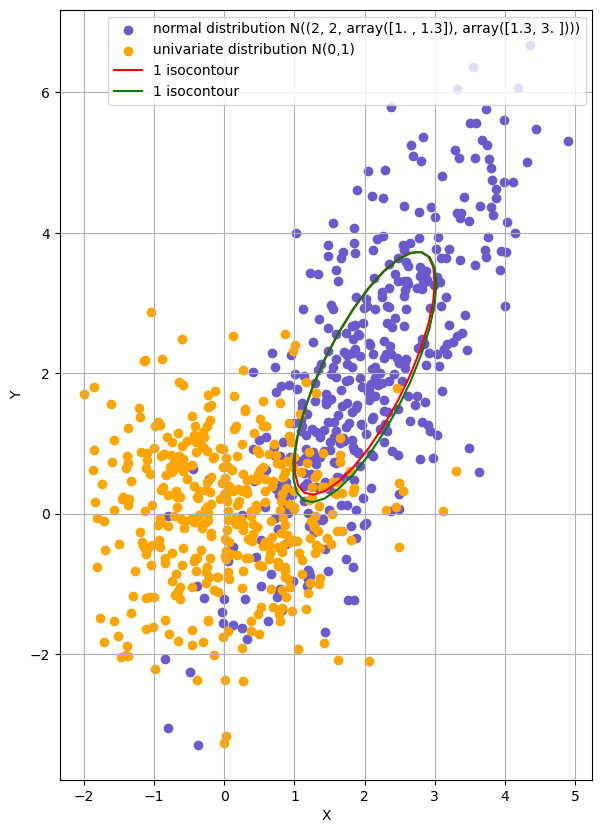

In [6]:
target_mean = np.array([2, 2])
target_cov = np.array([[1, 1.3], [1.3, 3]])

for n in [50, 200, 400]:
    # draw multivariate normal distribution and 1-isocontour
    cloud, ax = plot2dcov(target_mean, target_cov, n, [1], plot_univariate=True, plot_target=True, return_cloud=True)
    # calculate sample {mean, cov} and plot 1-isocontour
    sample_mean = 1. / n * np.sum(cloud, axis=0)
    sample_cov = 1. / (n - 1) * (cloud - sample_mean).T @ (cloud - sample_mean)

    assert np.allclose(sample_mean, np.mean(cloud, axis=0))
    assert np.allclose(sample_cov, np.cov(cloud, rowvar=False))
    
    plot2dcov(sample_mean, sample_cov, n, [1], ax, c=["green"])
    print("sample_cov:", sample_cov)

## Comments
### Task A
In this task multiple Gaussian distributions and their 1,2,3-sigma isocontours were plotted. According to the visualizations, 3-sigma isocontour includes almost all points, while 1-sigma isocontour includes points which are located closely to the peak of Gaussian distribution. 
### Task C
In this task the particular Gaussian distribution and its 1-sigma isocontour (red) were plotted using a multiple amount of points (50, 200, 400). In each case sample mean and sample covariance were calculated and this data was used to calculate and plot another 1-sigma isocontour (green). According to the results, the less points of distribution, the more discrepancy between 1-sigma isocontours. The more points are used, the less discrepancy between isocontours. In the case of 400 points, 1-sigma isocontours almost coincide.

# Task 3

## A

$$\left[\begin{matrix}x \\ y\end{matrix}\right]_t=\left[\begin{matrix}1 & 0 \\ 0 & 1\end{matrix}\right]\left[\begin{matrix}x \\ y\end{matrix}\right]_{t-1}+\left[\begin{matrix} \Delta t & 0 \\ 0 & \Delta t \end{matrix}\right] \left[\begin{matrix}u_x \\ u_y\end{matrix}\right]_t+\left[\begin{matrix}\eta_x \\ \eta_y\end{matrix}\right]_t,\ \ u_t=[u_x, u_y]^T,\ \ \left[\begin{matrix}\eta_x \\ \eta_y\end{matrix}\right]_t \thicksim N\left(\left[\begin{matrix}0 \\ 0\end{matrix}\right], \left[\begin{matrix}0.1 & 0 \\ 0 & 0.1 \end{matrix}\right] \right) = N\left(E\left(\left[\begin{matrix}\eta_x \\ \eta_y\end{matrix}\right]\right), R\right),\ \ \Delta t = 0.5$$
or
$$x_t = Ax_{t-1}+Bu_t+\epsilon_t$$
where $x_t=[x, y]_t^T$, $\epsilon_t=[\eta_x, \eta_y]_t^T$

Single propagation of an omni-directional robotic platform:
$$\mu_t=E(x_t)=E(Ax_{t-1}+B u_t+\epsilon_t)=E(Ax_{t-1})+E(B u_t)+E(\epsilon_t)=A\mu_{t-1}+B u_t$$
$$\Sigma_t=E((x_t-\mu_t)(x_t-\mu_t)^T)= E(Ax_{t-1}+B u_t+\epsilon_t -A\mu_{t-1}-Bu_t)(Ax_{t-1}+B u_t+\epsilon_t -A\mu_{t-1}-Bu_t)^T =\\=E((Ax_{t-1}-A\mu_{t-1})(Ax_{t-1}-A\mu_{t-1})^T+(Ax_{t-1}-A\mu_{t-1})\epsilon_t^T+\epsilon_t(Ax_{t-1}-A\mu_{t-1})^T+\epsilon_t\epsilon_t^T)=A\Sigma_{t-1}A^T+R$$
Thus
$$x_t \thicksim N(A\mu_{t-1}+Bu_t, A\Sigma_{t-1}A^T+R)$$

## B

Starting from initial state $x_0 \thicksim N(\mu_0, \Sigma_0)$ we are updating $x_1$ using the formulas above. And so on, until we don't reach current state $x_t$.

## C

In [7]:
def propagate(mean, cov, A, B, R, u):
    return A @ mean + B @ u, A @ cov @ A.T + R

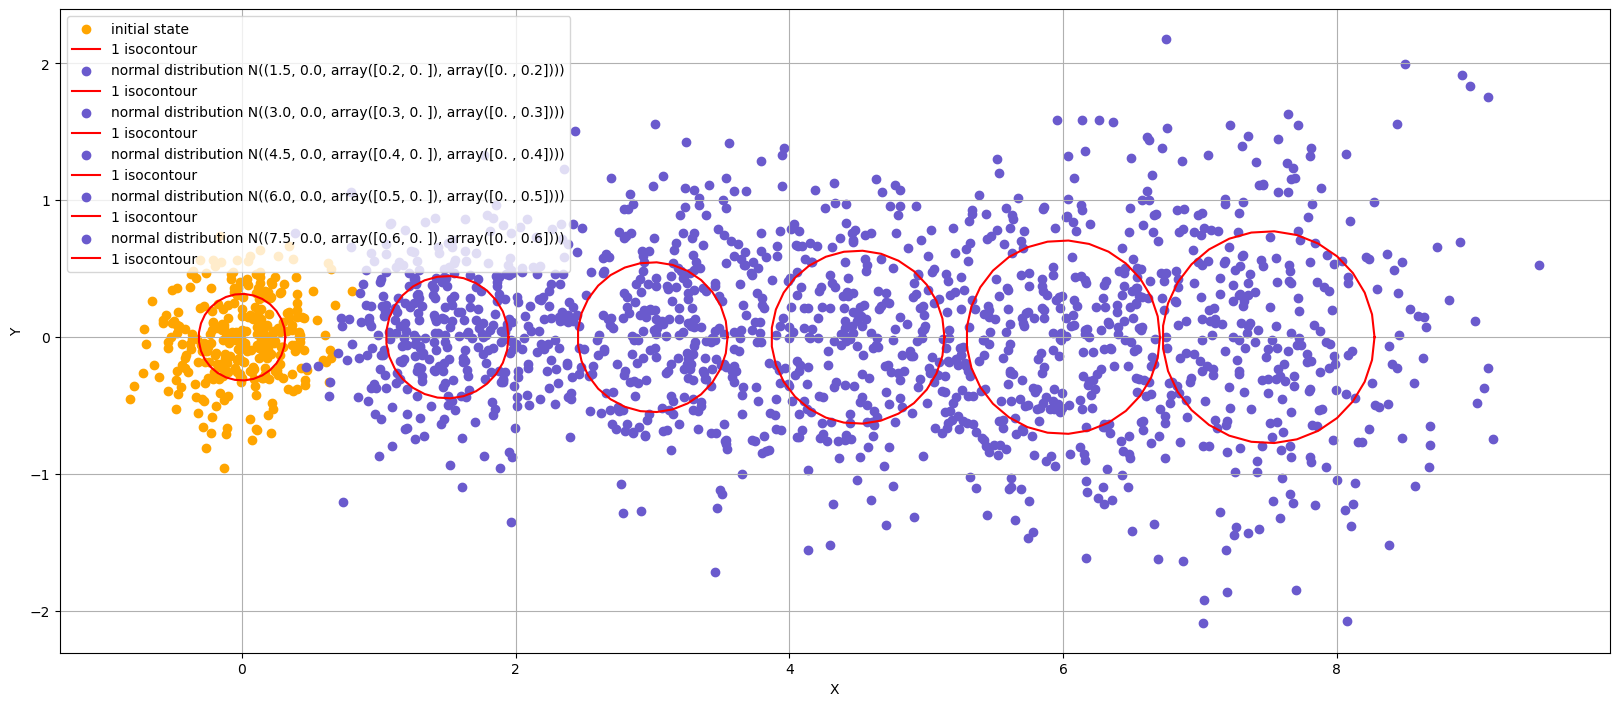

In [8]:
mean = np.array([0,0])
cov = np.array([[0.1, 0], [0, 0.1]])
delta_t = 0.5
A = np.eye(2)
B = np.eye(2) * delta_t
u = np.array([3, 0])
R = np.eye(2) * 0.1

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
x = np.random.multivariate_normal(mean, cov, 300)
ax.scatter(x[:,0], x[:,1], label='initial state', c='orange')
plot2dcov(mean, cov, k=[1], ax=ax)

for ti in range(1, 6):
    mean, cov = propagate(mean, cov, A, B, R, u)
    cloud, ax = plot2dcov(mean, cov, k=[1], ax=ax, plot_target=True, return_cloud=True)

## D

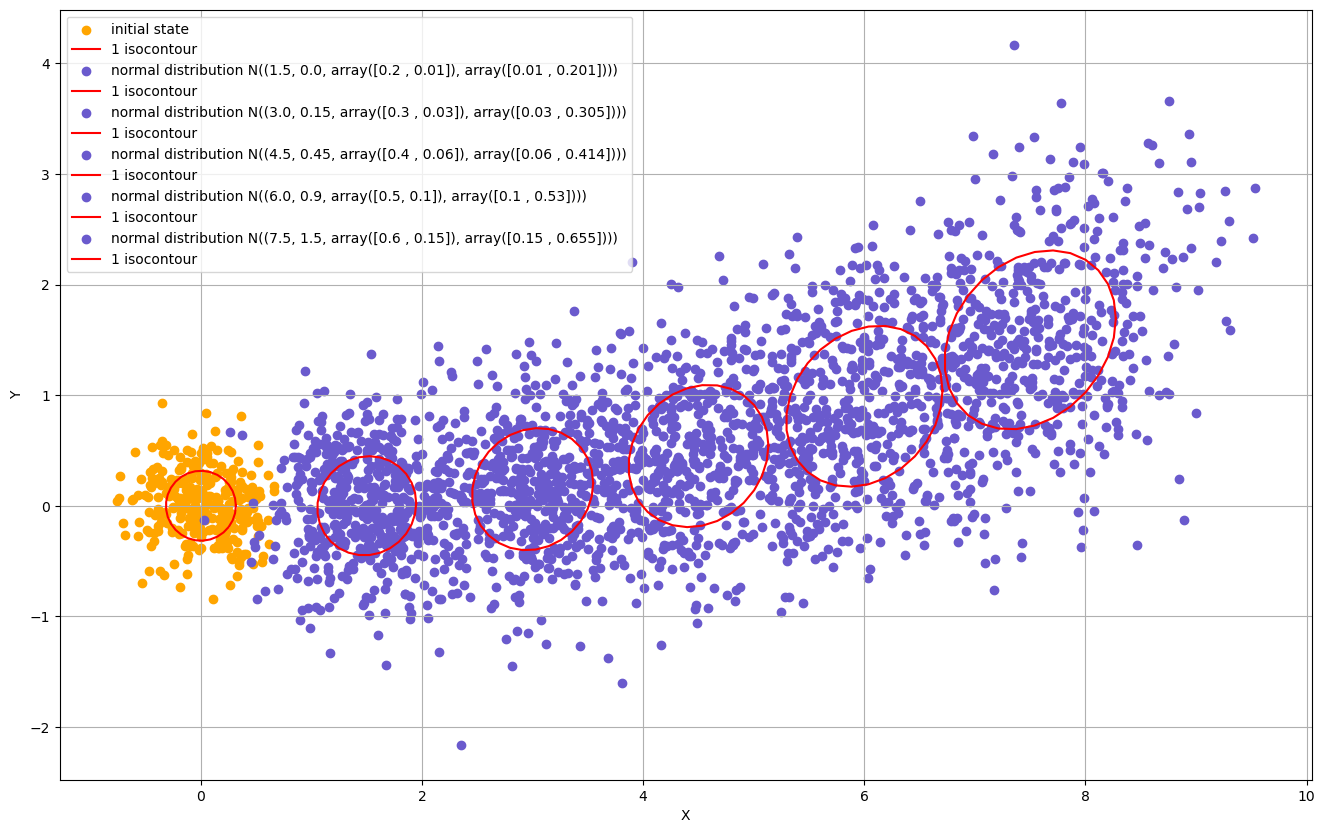

In [9]:
mean = np.array([0,0])
cov = np.array([[0.1, 0], [0, 0.1]])
delta_t = 0.5
A = np.array([[1, 0], [0.1, 1]])
B = np.eye(2) * delta_t
u = np.array([3, 0])
R = np.eye(2) * 0.1

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
x = np.random.multivariate_normal(mean, cov, 300)
ax.scatter(x[:,0], x[:,1], label='initial state', c='orange')
plot2dcov(mean, cov, 500, k=[1], ax=ax)

for ti in range(1, 6):
    mean, cov = propagate(mean, cov, A, B, R, u)
    cloud, ax = plot2dcov(mean, cov, 500, k=[1], ax=ax, plot_target=True, return_cloud=True)

## E

In [10]:
def propagate_non_holonomic(mean, cov, A, B, R, u, J):
    return A @ mean + B @ u, J @ cov @ J.T + R

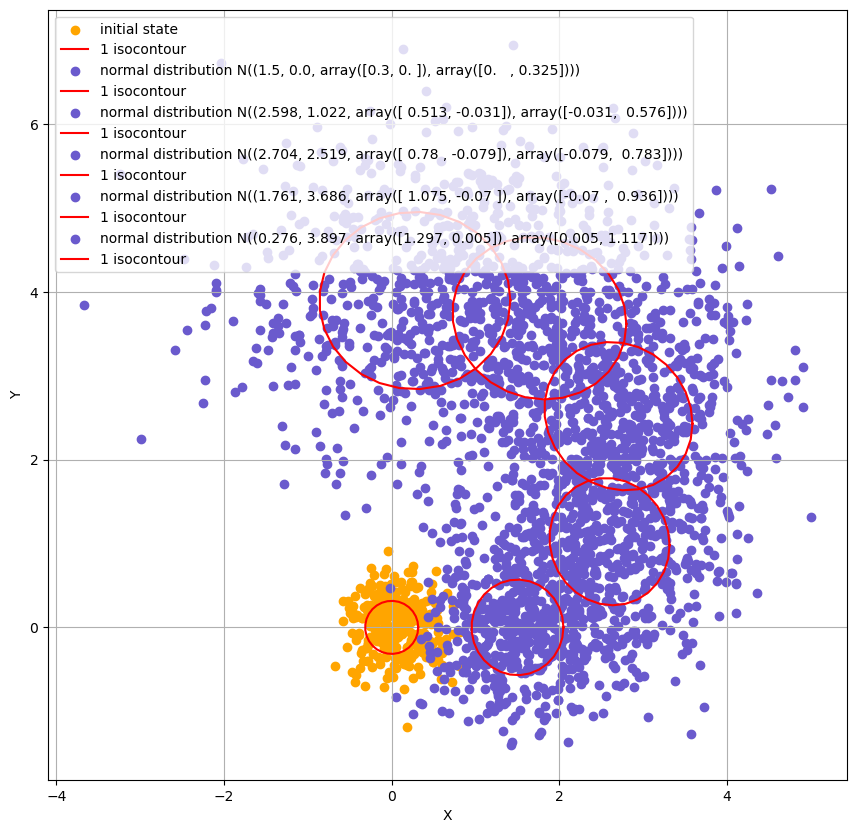

In [11]:
A = np.eye(3)
def B(theta):
    '''matrix B'''
    B = np.array([[np.cos(theta) * delta_t, 0],
                [np.sin(theta) * delta_t, 0],
                [0, delta_t]])
    return B

def J(theta):
    '''Jacobian'''
    J = np.array([[1, 0, -np.sin(theta) * delta_t],
                [0, 1, np.cos(theta) * delta_t],
                [0, 0, 1]])
    return J

R = np.array([[0.2, 0, 0], [0, 0.2, 0], [0, 0, 0.01]])
mean = np.zeros(3)
cov = np.eye(3) * 0.1
u = np.array([3, 1.5])

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
x = np.random.multivariate_normal(mean, cov, 300)
ax.scatter(x[:,0], x[:,1], label='initial state', c='orange')
plot2dcov(mean[:2], cov[:2,:2], 500, k=[1], ax=ax)

for ti in range(1,6):
    Ji = J(mean[2])
    Bi = B(mean[2])
    mean, cov = propagate_non_holonomic(mean, cov, A, Bi, R, u, Ji)
    cloud, ax = plot2dcov(mean[:2], cov[:2,:2], 500, k=[1], ax=ax, plot_target=True, return_cloud=True)


## F

In [12]:
def propagate_non_holonomic_action(mean, cov, A, B, R, u, J, V):
    return A @ mean + B @ u, J @ cov @ J.T + V @ R @ V.T

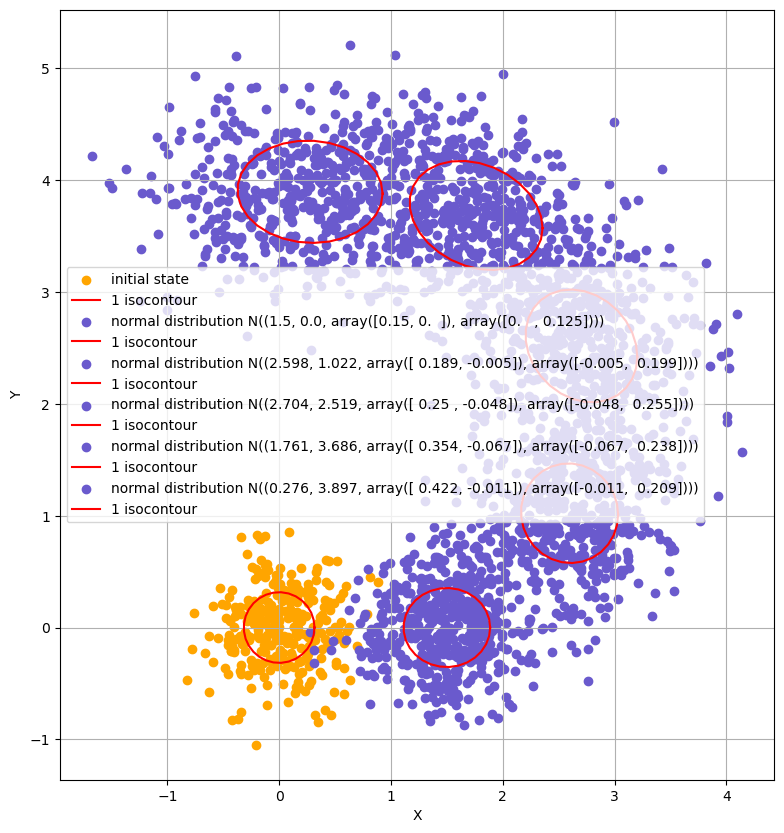

In [13]:
A = np.eye(3)
def B(theta):
    '''matrix B'''
    B = np.array([[np.cos(theta) * delta_t, 0],
                [np.sin(theta) * delta_t, 0],
                [0, delta_t]])
    return B

def J(theta):
    '''Jacobian over state'''
    J = np.array([[1, 0, -np.sin(theta) * delta_t],
                [0, 1, np.cos(theta) * delta_t],
                [0, 0, 1]])
    return J

def V(theta):
    '''Jacobian over action'''
    V = np.array([[np.cos(theta) * delta_t, 0],
                  [np.sin(theta) * delta_t, 0],
                  [0, delta_t]])
    return V

R = np.array([[0.2, 0], [0, 0.01]])
mean = np.zeros(3)
cov = np.eye(3) * 0.1
u = np.array([3, 1.5])

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
x = np.random.multivariate_normal(mean, cov, 300)
ax.scatter(x[:,0], x[:,1], label='initial state', c='orange')
plot2dcov(mean[:2], cov[:2,:2], 500, k=[1], ax=ax)

for ti in range(1,6):
    Ji = J(mean[2])
    Bi = B(mean[2])
    Vi = V(mean[2])
    mean, cov = propagate_non_holonomic_action(mean, cov, A, Bi, R, u, Ji, Vi)
    cloud, ax = plot2dcov(mean[:2], cov[:2,:2], 500, k=[1], ax=ax, plot_target=True, return_cloud=True)


In this task 1-sigma isocontours were plotted for the holonomic and non-holonomic platform. According to the plots we see that the state is changing linearly in the case of holonomic platform and non-linearly in the case of non-holonomic platform. For non-holonomic platform we considered 2 cases: 1) noise in state; 2) noise in action. The results differ in resulting distributions and isocontours, but the propagation pattern is the same.